<a href="https://colab.research.google.com/github/minoshim/Num_Analysis/blob/main/FVS/Py/Adv/fvs_adv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulation end at t = 0.150000


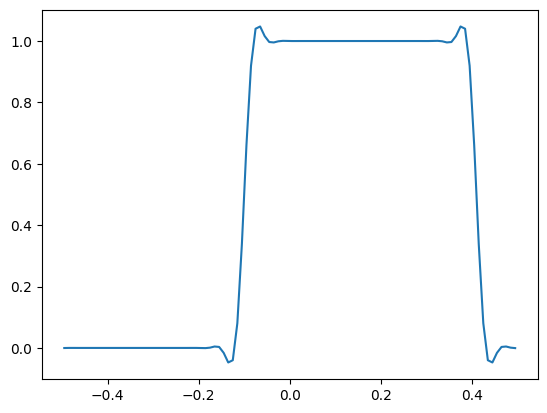

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# User-set parameters
## Spatial grid
xoff=2
xmesh=100
nx=xmesh+2*xoff
## Domain size, advection velocity, CFL number
lx=1.0
v=1.0
cfl=0.5
## Simulation time
tmax=0.15
# End of user-set parameters

# Grid width
dx=lx/xmesh
dt=np.abs(cfl*dx/v)
# Variables
x=np.zeros(nx)
f=np.zeros(nx)

# Functions
def init(x,f):                  # Initialize
    nx=len(f)
    i=np.arange(nx)
    x[:]=(i+0.5-xoff)*dx-0.5*lx
    f[:]=np.where((nx//4 < i) & (i < 3*nx//4), 1.0, 0.0)
    # f[:]=np.exp(-(x[:]*x[:])/(16*dx*dx))

def bc1d(f,xoff,dnx=0):         # Boundary condition
    nx = len(f)
    if dnx == 0:
        f[:xoff] = f[nx - 2*xoff : nx - xoff]
        f[nx - xoff:] = f[xoff : 2*xoff]
    elif abs(dnx) == 1:
        f[:xoff] = dnx * f[xoff : 2*xoff][::-1]
        f[nx - xoff:] = dnx * f[nx - 2*xoff : nx - xoff][::-1]

def fv3rd(f,v,dt,dx,xoff=2):       # 3rd-order finite-volume scheme
    nx=len(f)
    nu=v*dt/dx
    sgnv=np.sign(v)
    flux=np.zeros_like(f)
    flux[2:-1]=0.5*(+(1+sgnv)*(-f[0:-3]+5*f[1:-2]+2*f[2:-1])
                    +(1-sgnv)*(-f[3:  ]+5*f[2:-1]+2*f[1:-2]))/6.0
    f[xoff:nx-xoff]-=nu*(flux[xoff+1:nx-xoff+1]-flux[xoff:nx-xoff])

def csl3rd(f,v,dt,dx,xoff=2):       # 3rd-order conservative semi-Lagrangian scheme
    nx=len(f)
    nu=v*dt/dx
    sgnv=np.sign(v)
    flux=np.zeros_like(f)
    c0l=(-f[0:-3]+5*f[1:-2]+2*f[2:-1])/6.0
    c0r=(-f[3:  ]+5*f[2:-1]+2*f[1:-2])/6.0
    c1 =f[2:-1]-f[1:-2]
    c2l=(f[0:-3]-2*f[1:-2]+f[2:-1])*0.5
    c2r=(f[3:  ]-2*f[2:-1]+f[1:-2])*0.5
    ftl=c0l+nu*(-c1*0.5+c2l*nu/3.0)
    ftr=c0r+nu*(-c1*0.5+c2r*nu/3.0)
    flux[2:-1]=0.5*((1+sgnv)*ftl+(1-sgnv)*ftr)
    f[xoff:nx-xoff]-=nu*(flux[xoff+1:nx-xoff+1]-flux[xoff:nx-xoff])

def main(t,tmax):
    fcpy=np.zeros_like(f)
    while(t < tmax):
        bc1d(f,xoff,0)
        if (1):                 # 1 for SL scheme, 0 for FV-RK2 scheme
            csl3rd(f,v,dt,dx,xoff)
        else :
            fcpy=f.copy()
            fv3rd(f,v,dt,dx,xoff)
            bc1d(f,xoff,0)
            fv3rd(f,v,dt,dx,xoff)
            f[xoff:nx-xoff]=0.5*(f[xoff:nx-xoff]+fcpy[xoff:nx-xoff])
        t += dt
    return t

init(x,f)
t=main(0,tmax)
print(f"Simulation end at t = {t:.6f}")
plt.plot(x[xoff:-xoff],f[xoff:-xoff])
plt.show()